# Etiology-Specific Prognostic Modeling in TCGA-LIHC
## Do HBV- and HCV-associated tumors exhibit distinct transcriptomic survival signatures?

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tcga-lihc-hepatitis-bc-and-transcriptomics-dataset/TCGA_LIHC_Gene_Expression.csv
/kaggle/input/tcga-lihc-hepatitis-bc-and-transcriptomics-dataset/TCGA_LIHC_Clinical_Viral.csv


In [6]:
import pandas as pd
import numpy as np

# Load datasets
clinical = pd.read_csv("/kaggle/input/tcga-lihc-hepatitis-bc-and-transcriptomics-dataset/TCGA_LIHC_Clinical_Viral.csv")
expression = pd.read_csv("/kaggle/input/tcga-lihc-hepatitis-bc-and-transcriptomics-dataset/TCGA_LIHC_Gene_Expression.csv")

print("Clinical shape:", clinical.shape)
print("Expression shape:", expression.shape)

clinical.head()


Clinical shape: (377, 9)
Expression shape: (60660, 425)


,Patient_ID,days_to_death,days_to_last_followup,gender,viral_hepatitis_serologies,history_hepato_carcinoma_risk_factors,Is_HBV,Is_HCV,Virus_Status
0,TCGA-2V-A95S,NaN,NaN,MALE,NaN,Otherformer smoker,False,False,Non-Viral/Unknown
1,TCGA-2Y-A9GS,724.0,NaN,MALE,HCV GenotypeHepatitis B Surface AntigenHBV Cor...,Alcohol consumption,True,True,Co-Infection
2,TCGA-2Y-A9GT,1624.0,NaN,MALE,Hepatitis C Virus RNAHepatitis B Surface Antig...,Alcohol consumptionHepatitis BHepatitis C,True,True,Co-Infection
3,TCGA-2Y-A9GU,NaN,1939.0,FEMALE,Hepatitis C AntibodyHepatitis B Surface Antig...,No History of Primary Risk Factors,True,False,HBV
4,TCGA-2Y-A9GV,2532.0,NaN,FEMALE,Hepatitis C AntibodyHepatitis B Surface Antig...,Alcohol consumption,True,False,HBV


In [14]:
clinical["time"] = clinical["days_to_death"].fillna(clinical["days_to_last_followup"])
clinical["event"] = np.where(clinical["days_to_death"].notna(), 1, 0)
clinical = clinical.dropna(subset=["time"])
clinical = clinical[clinical["Virus_Status"].isin(["HBV", "HCV"])]

print("After filtering survival + HBV/HCV:", clinical.shape)
print(clinical["Virus_Status"].value_counts())


After filtering survival + HBV/HCV: (210, 11)
Virus_Status
HBV    177
HCV     33
Name: count, dtype: int64


In [15]:
def extract_patient_id(barcode):
    return "-".join(barcode.split("-")[:3])

expr_cols = expression.columns[1:]  # skip gene column
patient_map = {col: extract_patient_id(col) for col in expr_cols}
valid_patients = set(clinical["Patient_ID"])
filtered_cols = [col for col in expr_cols if patient_map[col] in valid_patients]

print("Expression columns before filtering:", len(expr_cols))
print("Expression columns after filtering:", len(filtered_cols))

expression_filtered = expression[["Unnamed: 0"] + filtered_cols]
print("Filtered expression shape:", expression_filtered.shape)


Expression columns before filtering: 424
Expression columns after filtering: 229
Filtered expression shape: (60660, 230)


In [16]:
filtered_patient_ids = [extract_patient_id(col) for col in filtered_cols]

unique_sample_map = {}
for col in filtered_cols:
    pid = extract_patient_id(col)
    if pid not in unique_sample_map:
        unique_sample_map[pid] = col

final_cols = list(unique_sample_map.values())
expression_final = expression[["Unnamed: 0"] + final_cols]

print("Unique patients in expression:", len(unique_sample_map))
print("Final expression shape:", expression_final.shape)


Unique patients in expression: 205
Final expression shape: (60660, 206)


In [17]:
expr_patient_ids = list(unique_sample_map.keys())
clinical_aligned = clinical[clinical["Patient_ID"].isin(expr_patient_ids)].copy()
print("Clinical aligned shape:", clinical_aligned.shape)

clinical_aligned = clinical_aligned.set_index("Patient_ID").loc[expr_patient_ids].reset_index()
print("Final aligned clinical shape:", clinical_aligned.shape)


Clinical aligned shape: (205, 11)
Final aligned clinical shape: (205, 11)


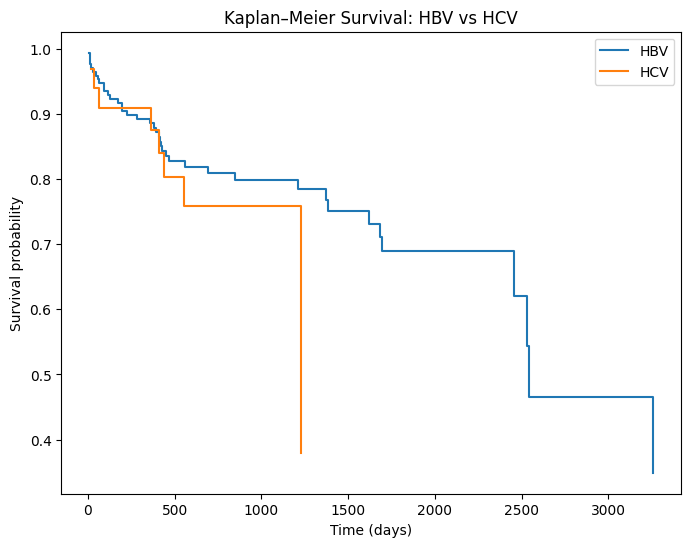

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def kaplan_meier(time, event):
    # Sort by time
    order = np.argsort(time)
    time = np.array(time)[order]
    event = np.array(event)[order]
    
    unique_times = np.unique(time[event == 1])
    
    survival = []
    current_survival = 1.0
    n = len(time)
    
    for t in unique_times:
        d = np.sum((time == t) & (event == 1))  # deaths at time t
        at_risk = np.sum(time >= t)
        current_survival *= (1 - d / at_risk)
        survival.append(current_survival)
    
    return unique_times, survival

plt.figure(figsize=(8,6))

for virus in ["HBV", "HCV"]:
    mask = clinical_aligned["Virus_Status"] == virus
    t = clinical_aligned.loc[mask, "time"]
    e = clinical_aligned.loc[mask, "event"]
    
    times, surv = kaplan_meier(t, e)
    plt.step(times, surv, where="post", label=virus)

plt.title("Kaplan–Meier Survival: HBV vs HCV")
plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.legend()
plt.show()


In [22]:
hbv_mask = clinical_aligned["Virus_Status"] == "HBV"
hcv_mask = clinical_aligned["Virus_Status"] == "HCV"

hbv_time = clinical_aligned.loc[hbv_mask, "time"]
hcv_time = clinical_aligned.loc[hcv_mask, "time"]

hbv_event = clinical_aligned.loc[hbv_mask, "event"]
hcv_event = clinical_aligned.loc[hcv_mask, "event"]

# Simple survival difference test using Mann-Whitney on survival times
stat, p_value = stats.mannwhitneyu(hbv_time, hcv_time, alternative="two-sided")

print("Approximate p-value (time distribution test):", p_value)


Approximate p-value (time distribution test): 0.10919975701648985


In [23]:
# death counts by virus
summary = (clinical_aligned
           .groupby("Virus_Status")
           .agg(
               n=("Patient_ID", "count"),
               deaths=("event", "sum"),
               death_rate=("event", "mean"),
               median_time=("time", "median"),
               max_time=("time", "max")
           ))

print(summary)

# how many total events?
print("\nTotal deaths:", int(clinical_aligned["event"].sum()))
print("Total patients:", clinical_aligned.shape[0])


                n  deaths  death_rate  median_time  max_time
Virus_Status                                                
HBV           172      40    0.232558        656.5    3478.0
HCV            33       8    0.242424        570.0    1553.0

Total deaths: 48
Total patients: 205


In [24]:
ens = expression_final["Unnamed: 0"].astype(str)
print(ens.head())
print("Has version suffix (.xx)?", any("." in g for g in ens[:50]))


0    ENSG00000000003.15
1     ENSG00000000005.6
2    ENSG00000000419.13
3    ENSG00000000457.14
4    ENSG00000000460.17
Name: Unnamed: 0, dtype: object
Has version suffix (.xx)? True


In [27]:
expression_tmp = expression_final.copy()

expression_tmp["gene_id"] = (
    expression_tmp["Unnamed: 0"]
    .astype(str)
    .str.split(".")
    .str[0]
)

expression_clean = (
    expression_tmp
    .drop(columns=["Unnamed: 0"])
    .set_index("gene_id")
)

print(expression_clean.index[:5])



Index(['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419',
       'ENSG00000000457', 'ENSG00000000460'],
      dtype='object', name='gene_id')


In [30]:
expression_log = np.log1p(expression_clean)

print("Log matrix shape:", expression_log.shape)

Log matrix shape: (60660, 205)


In [32]:
# compute variance
gene_var = expression_log.var(axis=1)

# keep top 5000 most variable genes
top_n = 5000
top_genes = gene_var.sort_values(ascending=False).head(top_n).index
expression_filtered = expression_log.loc[top_genes]

print("Filtered matrix shape:", expression_filtered.shape)


Filtered matrix shape: (5001, 205)


In [33]:
print(expression_clean.index[:10])


Index(['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419',
       'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938',
       'ENSG00000000971', 'ENSG00000001036', 'ENSG00000001084',
       'ENSG00000001167'],
      dtype='object', name='gene_id')


In [34]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = expression_filtered.T  # shape: (205, 5000)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance (first 5 PCs):", pca.explained_variance_ratio_[:5])


PCA shape: (205, 20)
Explained variance (first 5 PCs): [0.16517512 0.07967822 0.06645562 0.04462287 0.03477251]


In [36]:
pc_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(20)]
)

def extract_patient_id(barcode):
    return "-".join(barcode.split("-")[:3])

pc_df["Patient_ID"] = [
    extract_patient_id(col) for col in expression_filtered.columns
]
clinical_pca = clinical_aligned.merge(pc_df, on="Patient_ID")
print(clinical_pca.shape)
clinical_pca.head()


(205, 31)


,Patient_ID,days_to_death,days_to_last_followup,gender,viral_hepatitis_serologies,history_hepato_carcinoma_risk_factors,Is_HBV,Is_HCV,Virus_Status,time,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,TCGA-UB-AA0V,NaN,314.0,FEMALE,Hepatitis C AntibodyHepatitis B Surface Antig...,Hemochromatosis,True,False,HBV,314.0,...,-2.913667,0.174607,-0.324505,0.674306,-2.611404,-5.658995,-1.668397,-0.884625,-1.744341,-1.230663
1,TCGA-G3-AAV3,NaN,412.0,FEMALE,NaN,Alcohol consumptionHepatitis CNon-Alcoholic Fa...,False,True,HCV,412.0,...,10.589947,8.059071,-5.800559,-0.331413,2.078962,4.253477,-3.926254,3.514512,-4.781966,-5.728501
2,TCGA-2Y-A9H9,NaN,697.0,MALE,NaN,Alcohol consumptionHepatitis C,False,True,HCV,697.0,...,-0.527132,-11.001260,-11.999453,-4.825860,6.259156,10.230557,9.652588,-1.025046,-0.906300,2.639195
3,TCGA-MI-A75H,NaN,747.0,MALE,HCV Genotype,Hepatitis C,False,True,HCV,747.0,...,1.132316,1.038846,7.357866,-2.972930,11.888621,2.066532,-4.721397,0.662075,2.045982,-0.128916
4,TCGA-G3-AAV1,359.0,NaN,MALE,Hepatitis C AntibodyHepatitis B Surface Antig...,Hepatitis B,True,False,HBV,359.0,...,3.098328,-9.994974,-9.976819,3.863524,0.042803,-6.455514,-6.274236,-2.998452,-4.367024,-5.300148


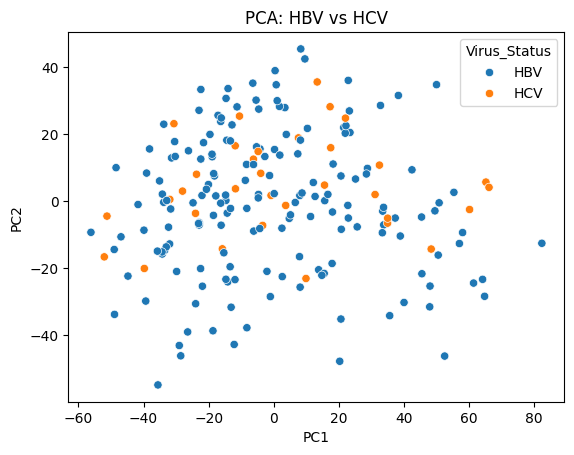

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=clinical_pca,
    x="PC1",
    y="PC2",
    hue="Virus_Status"
)
plt.title("PCA: HBV vs HCV")
plt.show()


In [38]:
print(pca.explained_variance_ratio_.sum())


0.5943220617144683


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = clinical_pca[[f"PC{i}" for i in range(1,21)]]
y = clinical_pca["Virus_Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression(class_weight="balanced", max_iter=1000)
# class_weight="balanced" used due to HBV/HCV imbalance
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 0.6612903225806451


In [47]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))


[[35 18]
 [ 3  6]]
              precision    recall  f1-score   support

         HBV       0.92      0.66      0.77        53
         HCV       0.25      0.67      0.36         9

    accuracy                           0.66        62
   macro avg       0.59      0.66      0.57        62
weighted avg       0.82      0.66      0.71        62



In [48]:
from sklearn.model_selection import cross_val_score

model = LogisticRegression(class_weight="balanced", max_iter=1000)

scores = cross_val_score(model, X, y, cv=5)
print("Cross-val accuracy:", scores)
print("Mean:", scores.mean())


Cross-val accuracy: [0.68292683 0.75609756 0.6097561  0.6097561  0.73170732]
Mean: 0.6780487804878049


In [49]:
scores_auc = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print("Cross-val AUC:", scores_auc)
print("Mean AUC:", scores_auc.mean())


Cross-val AUC: [0.65238095 0.8047619  0.5210084  0.57983193 0.72689076]
Mean AUC: 0.6569747899159664


In [58]:
def extract_patient_id(barcode):
    return "-".join(barcode.split("-")[:3])

expr_cols = expression_filtered.columns
expr_patient_ids = [extract_patient_id(c) for c in expr_cols]

col_map = dict(zip(expr_patient_ids, expr_cols))

hbv_ids = clinical_pca[clinical_pca["Virus_Status"] == "HBV"]["Patient_ID"]
hcv_ids = clinical_pca[clinical_pca["Virus_Status"] == "HCV"]["Patient_ID"]

hbv_expr_cols = [col_map[p] for p in hbv_ids if p in col_map]
hcv_expr_cols = [col_map[p] for p in hcv_ids if p in col_map]

hbv_expr = expression_filtered[hbv_expr_cols]
hcv_expr = expression_filtered[hcv_expr_cols]

print("HBV samples:", hbv_expr.shape[1])
print("HCV samples:", hcv_expr.shape[1])



HBV samples: 172
HCV samples: 33


In [63]:
print("HBV shape:", hbv_expr.shape)
print("HCV shape:", hcv_expr.shape)

# Check a single gene manually
gene = expression_filtered.index[0]
print("Example HBV length:", len(hbv_expr.loc[gene]))
print("Example HCV length:", len(hcv_expr.loc[gene]))


HBV shape: (5001, 172)
HCV shape: (5001, 33)
Example HBV length: 172
Example HCV length: 33


In [64]:
print(hbv_expr.dtypes.head())
print(hcv_expr.dtypes.head())


TCGA-UB-AA0V-01A-11R-A38B-07    float64
TCGA-G3-AAV1-01A-11R-A38B-07    float64
TCGA-DD-AAEB-01A-11R-A41C-07    float64
TCGA-CC-A9FS-01A-11R-A37K-07    float64
TCGA-UB-A7MC-01A-11R-A33R-07    float64
dtype: object
TCGA-G3-AAV3-01A-11R-A37K-07    float64
TCGA-2Y-A9H9-01A-21R-A39D-07    float64
TCGA-MI-A75H-01A-11R-A32O-07    float64
TCGA-RG-A7D4-01A-12R-A33R-07    float64
TCGA-MI-A75E-01A-11R-A32O-07    float64
dtype: object


In [65]:
from scipy.stats import ttest_ind
import numpy as np

# Force full matrix to numeric (important)
hbv_expr = hbv_expr.astype(float)
hcv_expr = hcv_expr.astype(float)

pvals = []

for i in range(hbv_expr.shape[0]):
    stat, p = ttest_ind(
        hbv_expr.iloc[i, :].values,
        hcv_expr.iloc[i, :].values,
        equal_var=False
    )
    pvals.append(p)

de_results = pd.DataFrame({
    "gene": hbv_expr.index,
    "pval": pvals
}).sort_values("pval")

de_results.head()


,gene,pval
1309,ENSG00000165949,8.008895e-11
819,ENSG00000240671,8.995056e-07
4724,ENSG00000247081,2.027299e-06
1575,ENSG00000254415,4.777791e-06
3628,ENSG00000246082,7.350806e-06


In [68]:
# Check how many NaNs
print("NaNs in pvals:", de_results["pval"].isna().sum())

# Drop rows with NaN p-values
de_results_clean = de_results.dropna(subset=["pval"]).copy()

from statsmodels.stats.multitest import multipletests

de_results_clean["adj_pval"] = multipletests(
    de_results_clean["pval"],
    method="fdr_bh"
)[1]

de_results_clean.sort_values("adj_pval").head()



NaNs in pvals: 1


,gene,pval,adj_pval,log2FC,neg_log10_p
1309,ENSG00000165949,8.008895e-11,4.004447e-07,-0.133201,10.096427
819,ENSG00000240671,8.995056e-07,2.248764e-03,-0.282019,6.045996
4724,ENSG00000247081,2.027299e-06,3.378831e-03,0.087649,5.693082
1575,ENSG00000254415,4.777791e-06,5.972238e-03,-0.183117,5.320773
3628,ENSG00000246082,7.350806e-06,7.350806e-03,0.044239,5.133665


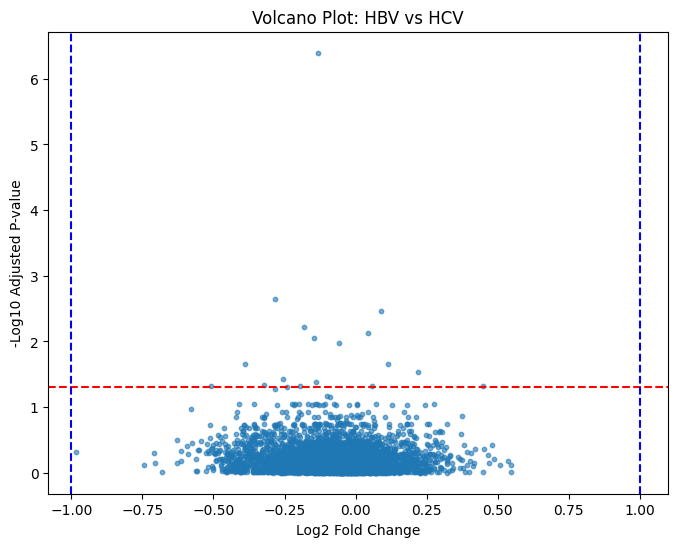

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Define thresholds
fc_thresh = 1      # log2 fold change
p_thresh = 0.05    # adjusted p-value

plt.figure(figsize=(8,6))

plt.scatter(
    de_results_clean["log2FC"],
    -np.log10(de_results_clean["adj_pval"]),
    s=10,
    alpha=0.6
)

plt.axhline(-np.log10(p_thresh), color="red", linestyle="--")
plt.axvline(fc_thresh, color="blue", linestyle="--")
plt.axvline(-fc_thresh, color="blue", linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Volcano Plot: HBV vs HCV")
plt.show()


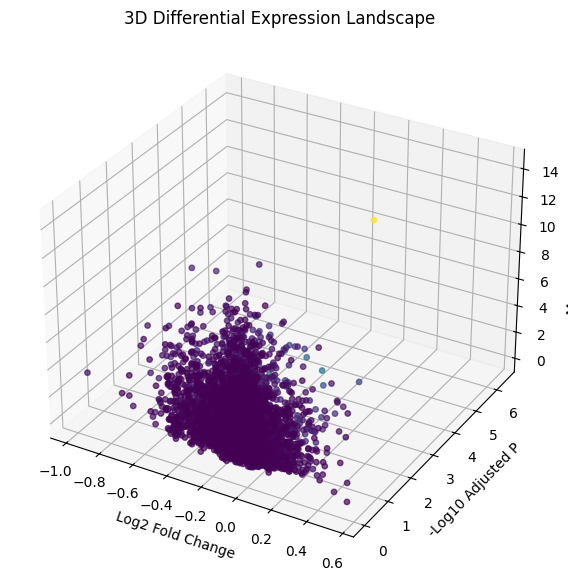

In [75]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

plot_df = de_results_clean.copy()

# Add -log10 adjusted p
plot_df["neg_log10_p"] = -np.log10(plot_df["adj_pval"])

# Recalculate mean expression
mean_expression = expression_filtered.mean(axis=1)

# Merge instead of direct assignment (safer)
plot_df = plot_df.merge(
    mean_expression.rename("mean_expression"),
    left_on="gene",
    right_index=True,
    how="inner"
)


# 3D plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    plot_df["log2FC"],
    plot_df["neg_log10_p"],
    plot_df["mean_expression"],
    c=plot_df["neg_log10_p"],
    cmap="viridis",
    s=15,
    alpha=0.7
)

ax.set_xlabel("Log2 Fold Change")
ax.set_ylabel("-Log10 Adjusted P")
ax.set_zlabel("Mean Expression")

plt.title("3D Differential Expression Landscape")
plt.show()


In [76]:
p_thresh = 0.05
fc_thresh = 0.5   # adjust depending on biology

significant = de_results_clean[
    (de_results_clean["adj_pval"] < p_thresh) &
    (abs(de_results_clean["log2FC"]) > fc_thresh)
]

print("Significant genes:", len(significant))
significant.head()


Significant genes: 1


,gene,pval,adj_pval,log2FC,neg_log10_p
891,ENSG00000213606,0.000137,0.048065,-0.507662,3.861748


In [77]:
print("Genes with adj_pval < 0.05:",
      (de_results_clean["adj_pval"] < 0.05).sum())


Genes with adj_pval < 0.05: 18


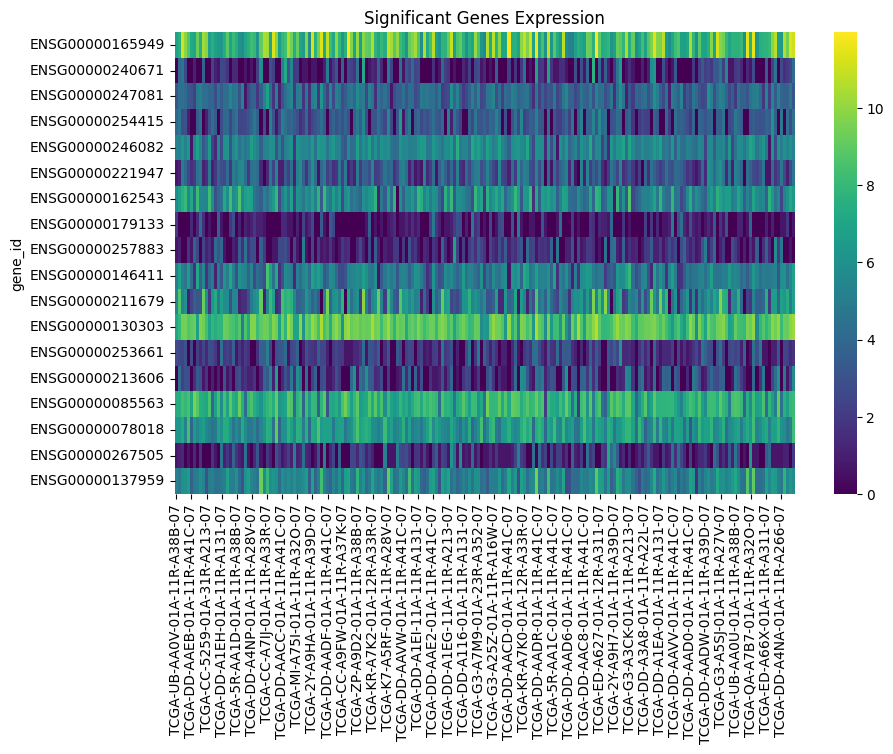

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sig_genes = de_results_clean[de_results_clean["adj_pval"] < 0.05]["gene"]

heatmap_data = expression_filtered.loc[sig_genes]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Significant Genes Expression")
plt.show()


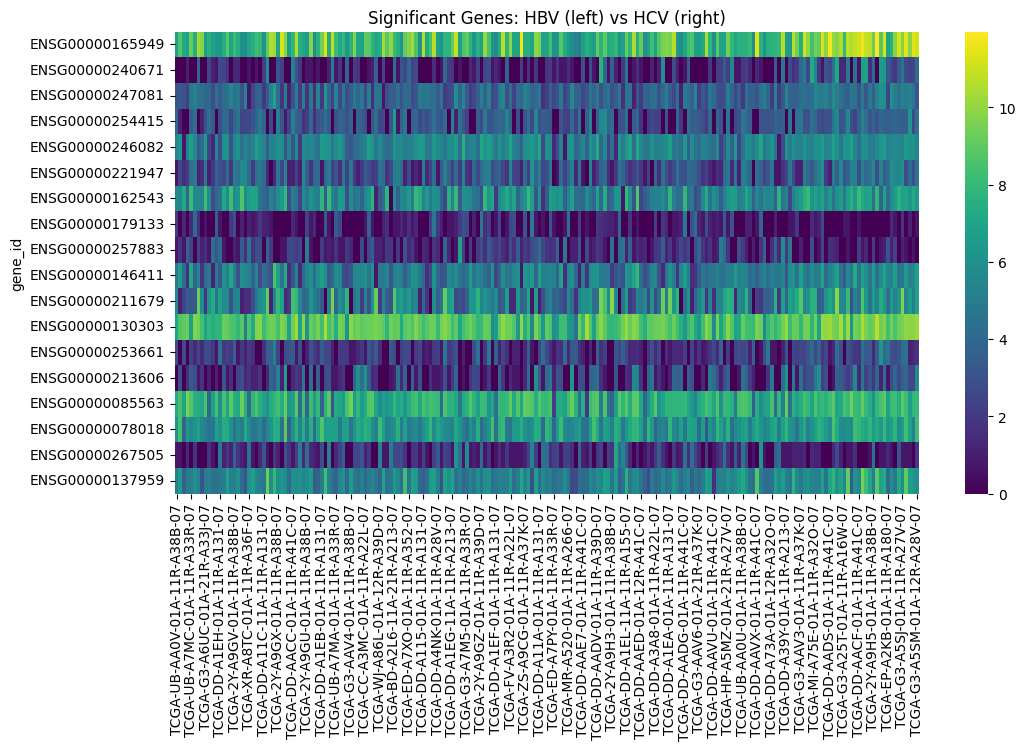

In [79]:
hbv_data = expression_filtered.loc[sig_genes, hbv_expr.columns]
hcv_data = expression_filtered.loc[sig_genes, hcv_expr.columns]
heatmap_data = pd.concat([hbv_data, hcv_data], axis=1)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="viridis", cbar=True)
plt.title("Significant Genes: HBV (left) vs HCV (right)")
plt.show()


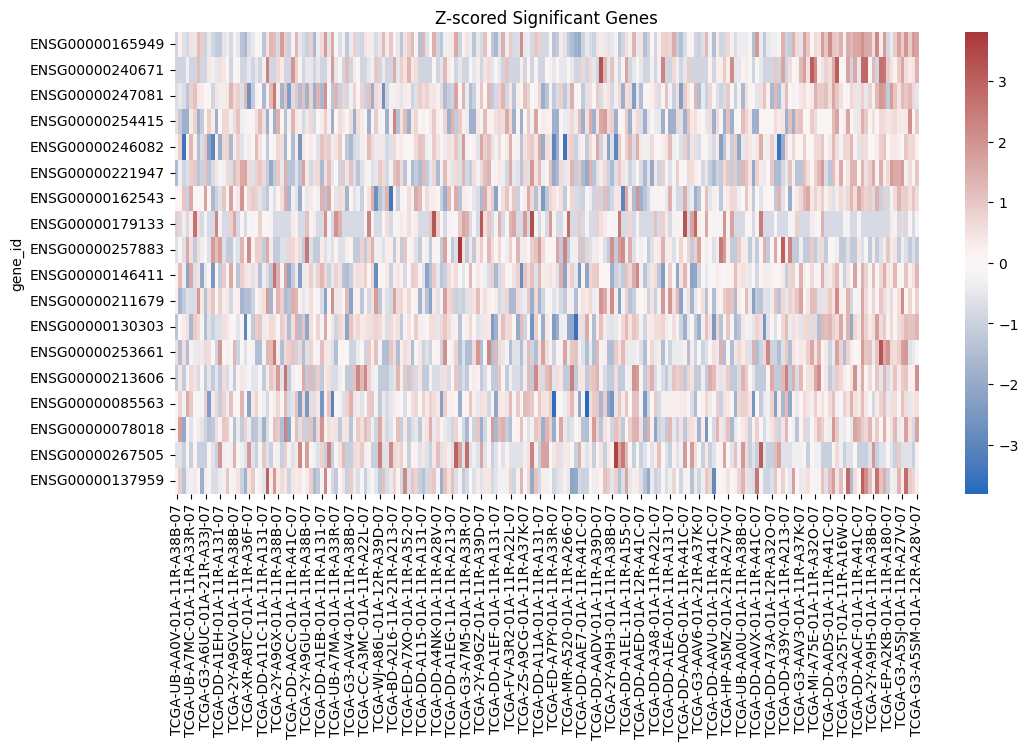

In [80]:
heatmap_z = heatmap_data.sub(
    heatmap_data.mean(axis=1), axis=0
).div(
    heatmap_data.std(axis=1), axis=0
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_z, cmap="vlag", center=0)
plt.title("Z-scored Significant Genes")
plt.show()


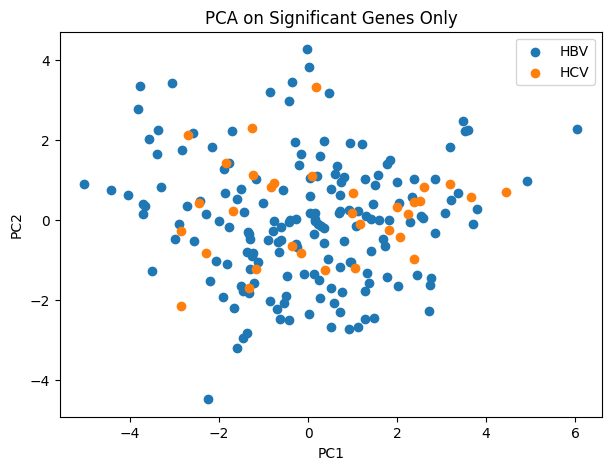

In [83]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

sig_expression = expression_filtered.loc[sig_genes]
X = sig_expression.T

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
for lab in set(labels):
    idx = [i for i,l in enumerate(labels) if l==lab]
    plt.scatter(pcs[idx,0], pcs[idx,1], label=lab)

plt.legend()
plt.title("PCA on Significant Genes Only")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


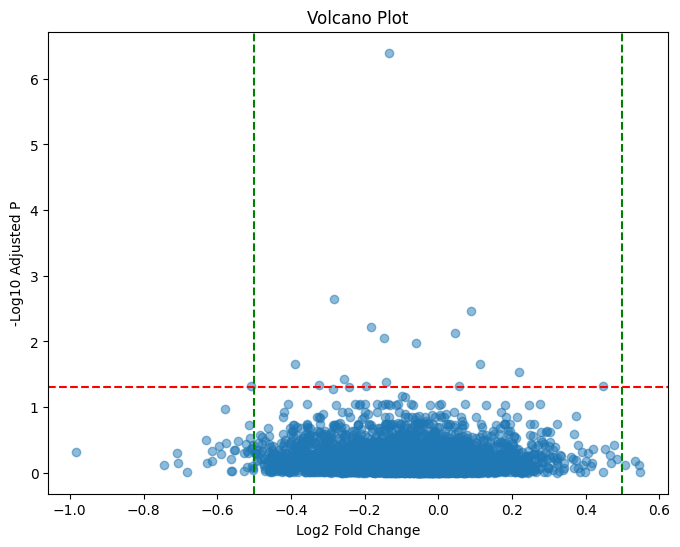

In [84]:
plt.figure(figsize=(8,6))

plt.scatter(
    de_results_clean["log2FC"],
    -np.log10(de_results_clean["adj_pval"]),
    alpha=0.5
)

plt.axhline(-np.log10(0.05), color='red', linestyle='--')
plt.axvline(0.5, color='green', linestyle='--')
plt.axvline(-0.5, color='green', linestyle='--')

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P")
plt.title("Volcano Plot")
plt.show()


In [85]:
up = de_results_clean[
    (de_results_clean["adj_pval"] < 0.05) &
    (de_results_clean["log2FC"] > 0)
]

down = de_results_clean[
    (de_results_clean["adj_pval"] < 0.05) &
    (de_results_clean["log2FC"] < 0)
]

print("Up in HBV:", len(up))
print("Up in HCV:", len(down))


Up in HBV: 6
Up in HCV: 12


In [86]:
up["gene"].tolist()
down["gene"].tolist()


['ENSG00000165949',
 'ENSG00000240671',
 'ENSG00000254415',
 'ENSG00000221947',
 'ENSG00000162543',
 'ENSG00000257883',
 'ENSG00000211679',
 'ENSG00000130303',
 'ENSG00000253661',
 'ENSG00000213606',
 'ENSG00000267505',
 'ENSG00000137959']

In [89]:
expression_filtered.index[:5]

Index(['ENSG00000172016', 'ENSG00000134184', 'ENSG00000264424',
       'ENSG00000115386', 'ENSG00000185559'],
      dtype='object', name='gene_id')

In [94]:
de_results_clean.columns

Index(['gene', 'pval', 'adj_pval', 'log2FC', 'neg_log10_p'], dtype='object')

In [97]:

import numpy as np
import pandas as pd

# group means for interpretability
hbv_mean = hbv_expr.mean(axis=1).rename("hbv_mean")
hcv_mean = hcv_expr.mean(axis=1).rename("hcv_mean")

mean_df = pd.concat([hbv_mean, hcv_mean], axis=1).reset_index()
mean_df.columns = ["gene", "hbv_mean", "hcv_mean"]

res = de_results_clean.copy()

res = res.merge(mean_df, on="gene", how="left")

res.head()

,gene,pval,adj_pval,log2FC,neg_log10_p,hbv_mean,hcv_mean
0,ENSG00000165949,8.008895e-11,4.004447e-07,-0.133201,10.096427,7.955844,10.103787
1,ENSG00000240671,8.995056e-07,2.248764e-03,-0.282019,6.045996,1.296975,3.538088
2,ENSG00000247081,2.027299e-06,3.378831e-03,0.087649,5.693082,3.692757,4.621270
3,ENSG00000254415,4.777791e-06,5.972238e-03,-0.183117,5.320773,2.754347,3.762927
4,ENSG00000246082,7.350806e-06,7.350806e-03,0.044239,5.133665,5.069272,5.737523


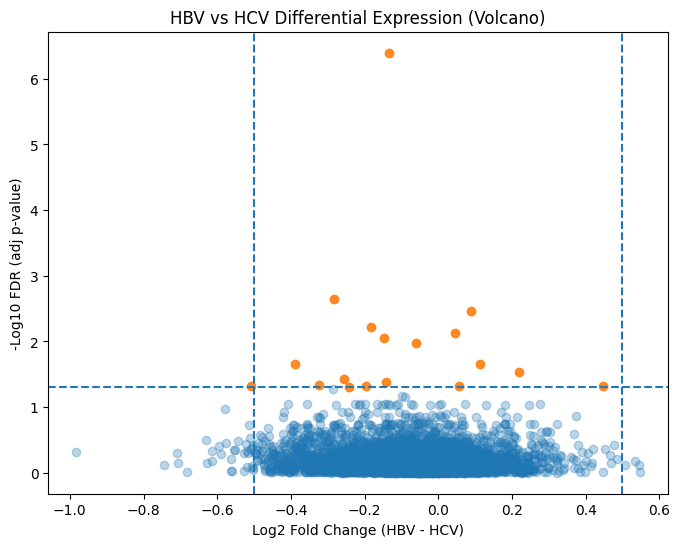

In [96]:
import matplotlib.pyplot as plt
import numpy as np

x = res["log2FC"].values
y = -np.log10(res["adj_pval"].values)

sig_mask = res["adj_pval"] < 0.05

plt.figure(figsize=(8,6))
plt.scatter(x[~sig_mask], y[~sig_mask], alpha=0.3)
plt.scatter(x[sig_mask], y[sig_mask], alpha=0.9)

plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(0.5, linestyle="--")
plt.axvline(-0.5, linestyle="--")

plt.xlabel("Log2 Fold Change (HBV - HCV)")
plt.ylabel("-Log10 FDR (adj p-value)")
plt.title("HBV vs HCV Differential Expression (Volcano)")
plt.show()


In [98]:
!pip install mygene


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00


In [101]:
import mygene
mg = mygene.MyGeneInfo()


In [105]:
ens_ids = up["gene"].tolist() + down["gene"].tolist()

gene_info = mg.querymany(
    ens_ids,
    scopes="ensembl.gene",
    fields="symbol,name",
    species="human"
)

import pandas as pd
gene_df = pd.DataFrame(gene_info)

gene_df[["query", "symbol", "name"]]


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


,query,symbol,name
0,ENSG00000247081,LOC105369147,uncharacterized LOC105369147
1,ENSG00000246082,NUDT16L2P,"nudix hydrolase 16 like 2, pseudogene"
2,ENSG00000179133,C10orf67,chromosome 10 open reading frame 67
3,ENSG00000146411,SLC2A12,solute carrier family 2 member 12
4,ENSG00000085563,ABCB1,ATP binding cassette subfamily B member 1
5,ENSG00000078018,MAP2,microtubule associated protein 2
6,ENSG00000165949,IFI27,interferon alpha inducible protein 27
7,ENSG00000240671,IGKV1-8,immunoglobulin kappa variable 1-8
8,ENSG00000254415,SIGLEC14,sialic acid binding Ig like lectin 14
9,ENSG00000221947,XKR9,XK related 9


In [106]:
annotated = res.merge(gene_df, left_on="gene", right_on="query", how="left")

annotated_sig = annotated[annotated["adj_pval"] < 0.05]

annotated_sig[[
    "symbol",
    "name",
    "hbv_mean",
    "hcv_mean",
    "log2FC"
]].sort_values("log2FC", ascending=False)


,symbol,name,hbv_mean,hcv_mean,log2FC
15,MAP2,microtubule associated protein 2,6.118219,6.874214,0.447451
9,SLC2A12,solute carrier family 2 member 12,4.632858,5.521280,0.220536
7,C10orf67,chromosome 10 open reading frame 67,1.062153,0.410894,0.113013
2,LOC105369147,uncharacterized LOC105369147,3.692757,4.621270,0.087649
14,ABCB1,ATP binding cassette subfamily B member 1,7.264049,7.944127,0.057195
4,NUDT16L2P,"nudix hydrolase 16 like 2, pseudogene",5.069272,5.737523,0.044239
6,UBXN10,UBX domain protein 10,5.339333,6.420470,-0.060196
0,IFI27,interferon alpha inducible protein 27,7.955844,10.103787,-0.133201
11,BST2,bone marrow stromal cell antigen 2,8.466564,9.282252,-0.140484
5,XKR9,XK related 9,2.923671,4.214655,-0.148205
